# <center> Deflection energy of a particle as a function of current </center>

In [93]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

from particletracker.fileparser import field_function_from_file
from particletracker.trajectory import solve_trajectory
from particletracker.trajanalysis import show_deviation_degree, show_deviation_in_Z, plot_2d_trajectory, plot_3d_trajectory


## 2. Simulation parameters

The main simulation parameters are defined below. Edit this parameters based on your needs.

In [94]:
''' ==== Particle features ==== '''
m = 939.3      # proton mass (MeV/c²)
q = 1          # proton charge (elementary charge)



''' === Initial conditions === '''
x0, y0, z0 = -0.07573, 0, -0.35                                     # initial coordinates (m)
v_direction = [((6**0.5)-(2**0.5))/4, 0, ((6**0.5)+(2**0.5))/4]     # velocity vector
Ec0 = 2                                                             # initial particle's kinetic energy 


''' === Trajectory solution === '''
method = 'boris'                     # choose between "boris" and "rk4"
total_t = 3e-7                       # total elapsed time (s)
step = total_t/1000                  # time step (s)
traj_distance = 0.685761             # total distance of particle's trajectory in X axis (m)



''' === Fields === '''
e_field = lambda ponto: [0, 0, 0]       # force electric field to be 0 at all points


''' === Files === '''
currents = [12.5, 10, 9.95, 7.5, 5, 2.5]          # list containing the current values associated with each field from following files (decrescent order)
files = ['2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=12.5A_ID=5479.dat',
         '2026-01-20_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=10.0A_ID=5484.dat',
         '2026-01-15_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=9.95A_ID=5475.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=7.5A_ID=5482.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=5.0A_ID=5477.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=2.5A_ID=5481.dat']    # list containing the names of all files

## 3. Simulation run

If you want to calculate the final position based on the deviation angle, use the follwing cell. Else, comment it.

In [95]:
'''desired_degree = 15.00

data = []

for file, current in zip(files, currents):
    Ec0 = 2
    print('-'*30)
    print(f'CURRENT CASE: {current} A')
    print('-'*30)

    b_field = field_function_from_file(file, '\t', 17)

    # run the simulation
    traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    dev_degree = show_deviation_degree(traj, traj_distance)

    print(f' Energy is: {Ec0}')


    while abs(dev_degree) < desired_degree:

        Ec0 = Ec0 - 0.15

        # run the simulation
        traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

        dev_degree = show_deviation_degree(traj, traj_distance)

        print(f' Energy is: {Ec0}')

    if abs(dev_degree) > desired_degree:
        while abs(dev_degree) > desired_degree:

            Ec0 = Ec0 + 0.01                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            dev_degree = show_deviation_degree(traj, traj_distance)

            print(f' Energy is: {Ec0}')


    if abs(dev_degree) < desired_degree:
        while abs(dev_degree) < desired_degree:

            Ec0 = Ec0 - 0.001                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            dev_degree = show_deviation_degree(traj, traj_distance)

            print(f' Energy is: {Ec0}')

    data += [[current, Ec0]]

chart = pd.DataFrame(data, columns=["Current(A)", "Energy(MeV)"])
'''


'desired_degree = 15.00\n\ndata = []\n\nfor file, current in zip(files, currents):\n    Ec0 = 2\n    print(\'-\'*30)\n    print(f\'CURRENT CASE: {current} A\')\n    print(\'-\'*30)\n\n    b_field = field_function_from_file(file, \'\t\', 17)\n\n    # run the simulation\n    traj = solve_trajectory(m, q, \n                            x0, y0, z0, v_direction, Ec0,\n                            b_field, e_field,\n                            method, step, total_t, \n                            output_file=\'traj_calculation_results\')\n\n    dev_degree = show_deviation_degree(traj, traj_distance)\n\n    print(f\' Energy is: {Ec0}\')\n\n\n    while abs(dev_degree) < desired_degree:\n\n        Ec0 = Ec0 - 0.15\n\n        # run the simulation\n        traj = solve_trajectory(m, q, \n                            x0, y0, z0, v_direction, Ec0,\n                            b_field, e_field,\n                            method, step, total_t, \n                            output_file=\'traj_calculati

If you want to calculate the final position based on the coordinates, use the follwing cell. Else, comment it.

In [96]:
desired_x = -0.071212
desired_z = 0.335761

data = []

for file, current in zip(files, currents):
    print('-'*30)
    print(f'CURRENT CASE: {current} A')
    print('-'*30)

    b_field = field_function_from_file(file, '\t', 17)

    traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    final_x = show_deviation_in_Z(traj, desired_z)

    print(f' Energy is: {Ec0}')


    while final_x < desired_x:

        Ec0 = Ec0 + 0.1

        traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

        final_x = show_deviation_in_Z(traj, desired_z)

        print(f' Energy is: {Ec0}')

    if final_x > desired_x:
        while final_x > desired_x:

            Ec0 = Ec0 - 0.01               
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            final_x = show_deviation_in_Z(traj, desired_z)

            print(f' Energy is: {Ec0}')


    if final_x < desired_x:
        while final_x < desired_x:

            Ec0 = Ec0 + 0.001          
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            final_x = show_deviation_in_Z(traj, desired_z)

            print(f' Energy is: {Ec0}')


    
    if final_x > desired_x:
        while final_x > desired_x:

            Ec0 = Ec0 - 0.0001        
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            final_x = show_deviation_in_Z(traj, desired_z)

            print(f' Energy is: {Ec0}')

    data += [[current, Ec0]]

chart = pd.DataFrame(data, columns=["Current(A)", "Energy(MeV)"])

------------------------------
CURRENT CASE: 12.5 A
------------------------------
Z1 = 0.3369437539169216
The final x value is approximately -0.09498997767275039
 Energy is: 2
Z1 = 0.3375834287902785
The final x value is approximately -0.08977564936326622
 Energy is: 2.1
Z1 = 0.33687810890338304
The final x value is approximately -0.08496128850696771
 Energy is: 2.2
Z1 = 0.3409165004358926
The final x value is approximately -0.08050079913796113
 Energy is: 2.3000000000000003
Z1 = 0.3378487662904658
The final x value is approximately -0.07635122826219456
 Energy is: 2.4000000000000004
Z1 = 0.3399240302947597
The final x value is approximately -0.07247776773716086
 Energy is: 2.5000000000000004
Z1 = 0.3411503320193897
The final x value is approximately -0.068850438785898
 Energy is: 2.6000000000000005
Z1 = 0.33977453818392345
The final x value is approximately -0.06920267886054321
 Energy is: 2.5900000000000007
Z1 = 0.3383961224218443
The final x value is approximately -0.06955748742730

## 4. Results

The following cells show the results obtained from the simulation. If you don't want to visualise something, just comment the cell where it is called.

### 4.1. Trajectory plotting

Plots some informations about particle's trajectory.

TRAJECTORY (12.5 A)


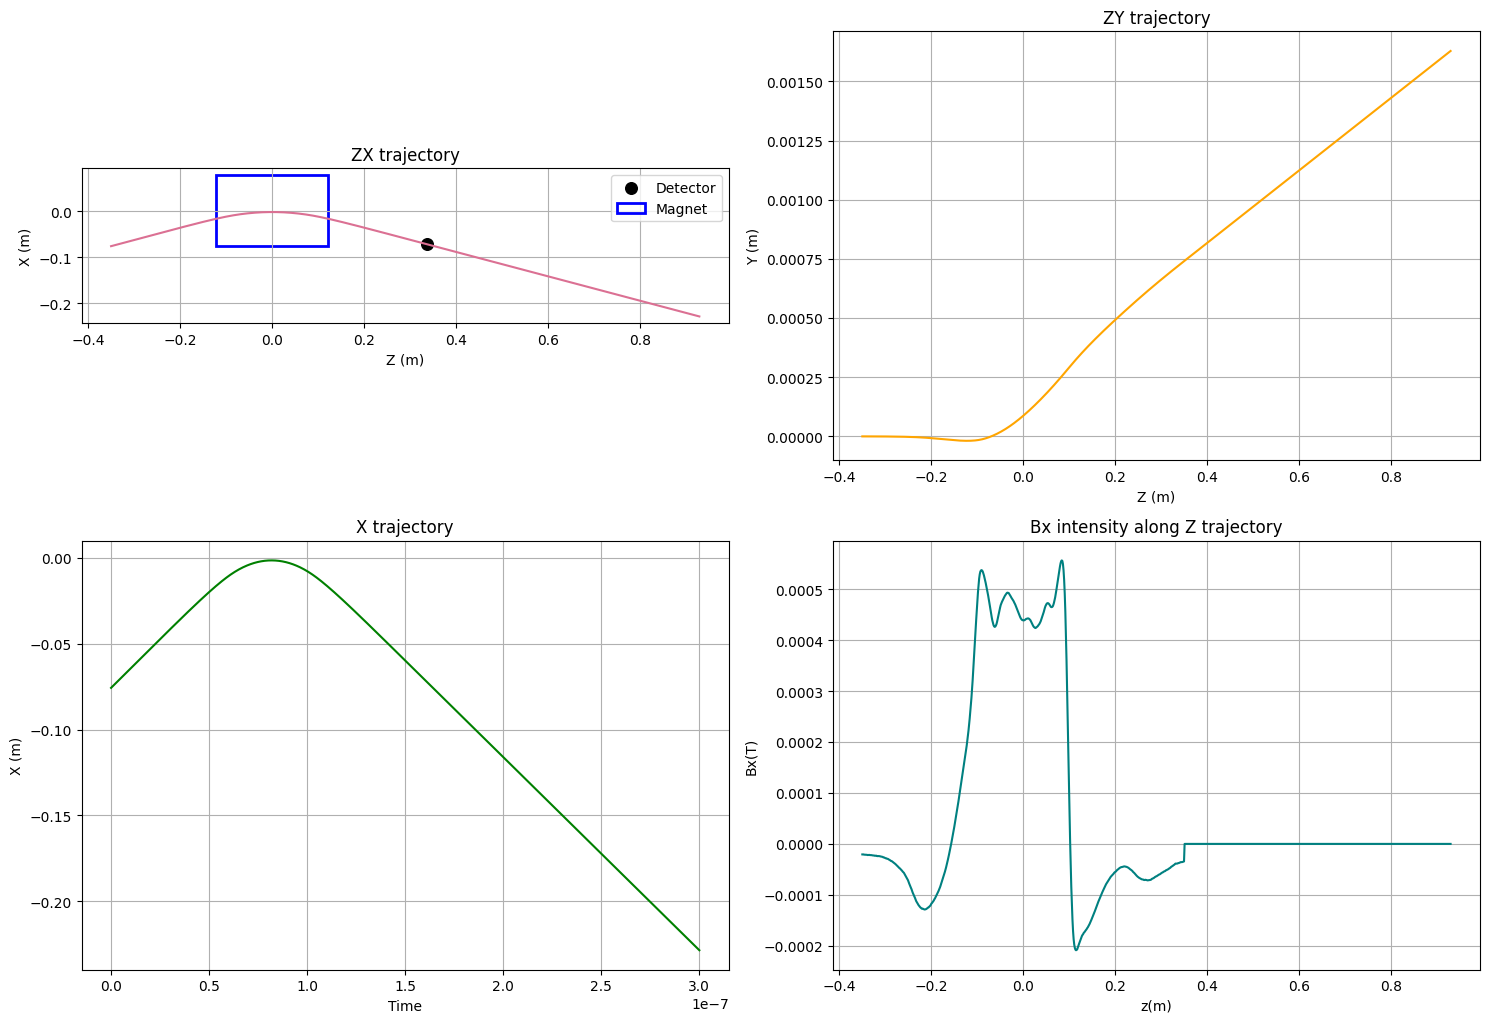

TRAJECTORY (10 A)


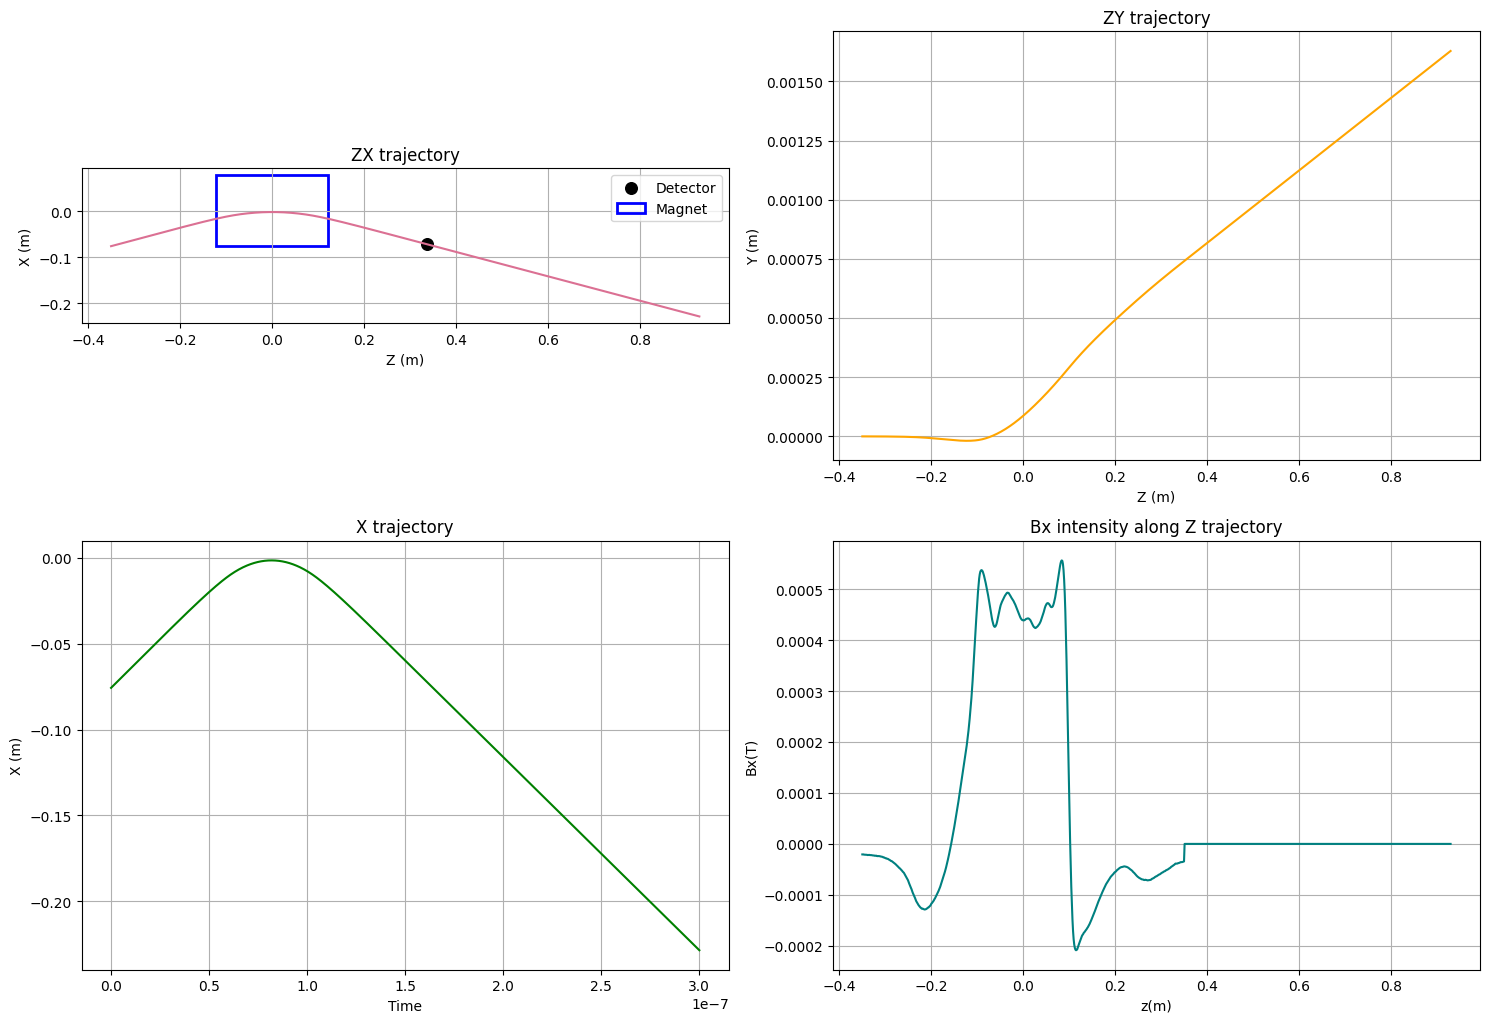

TRAJECTORY (9.95 A)


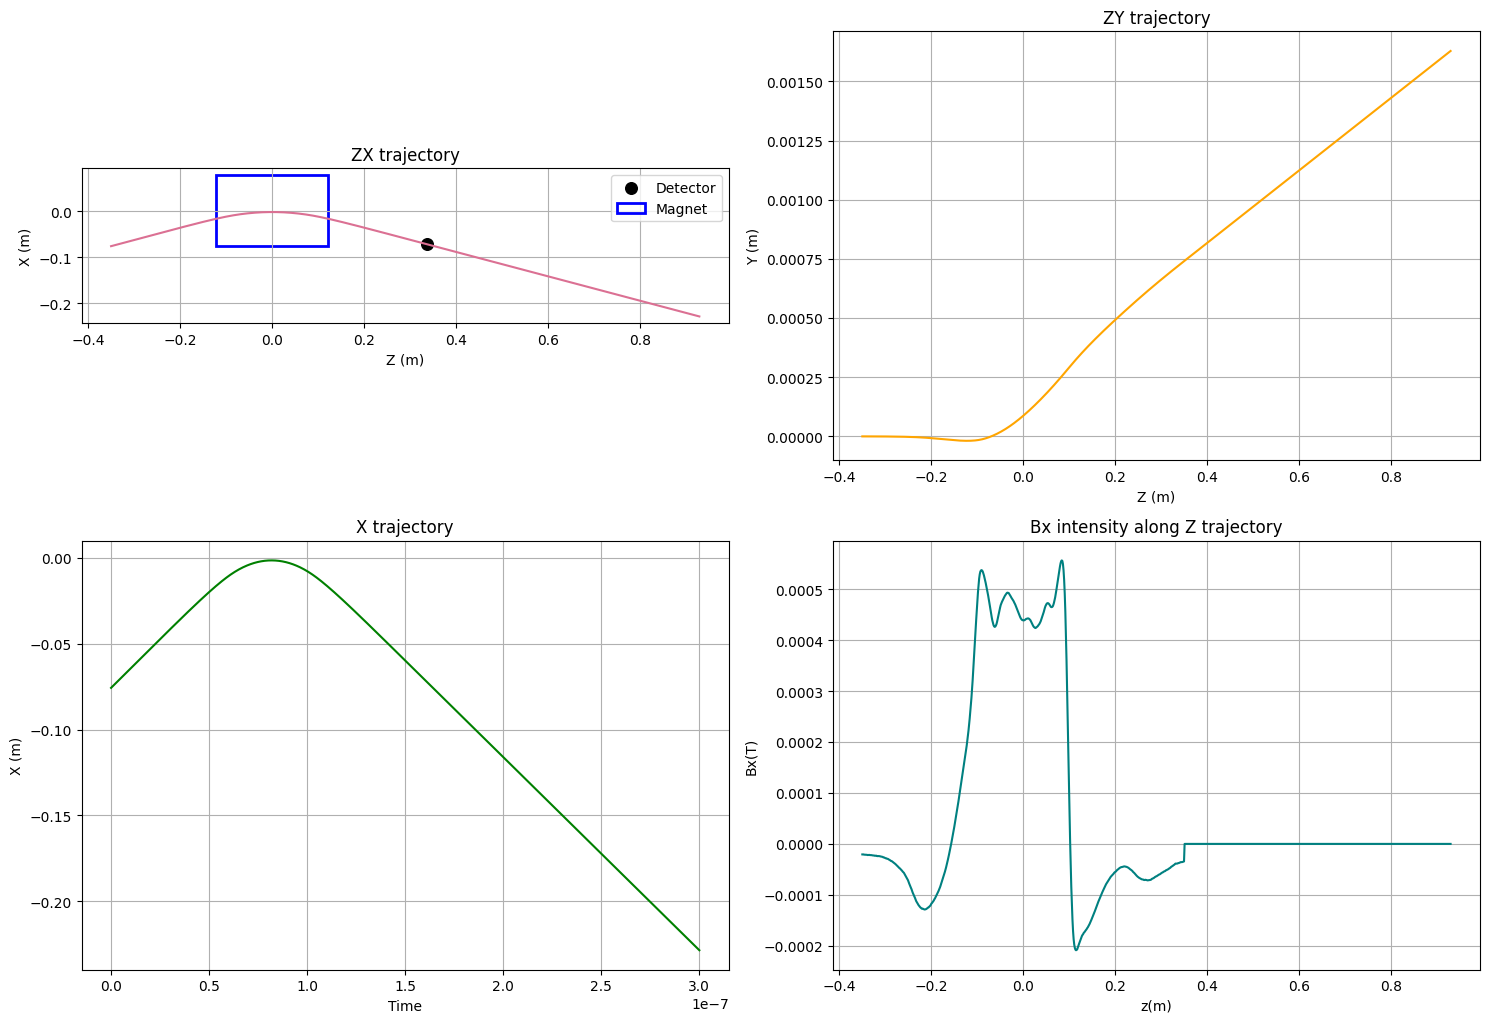

TRAJECTORY (7.5 A)


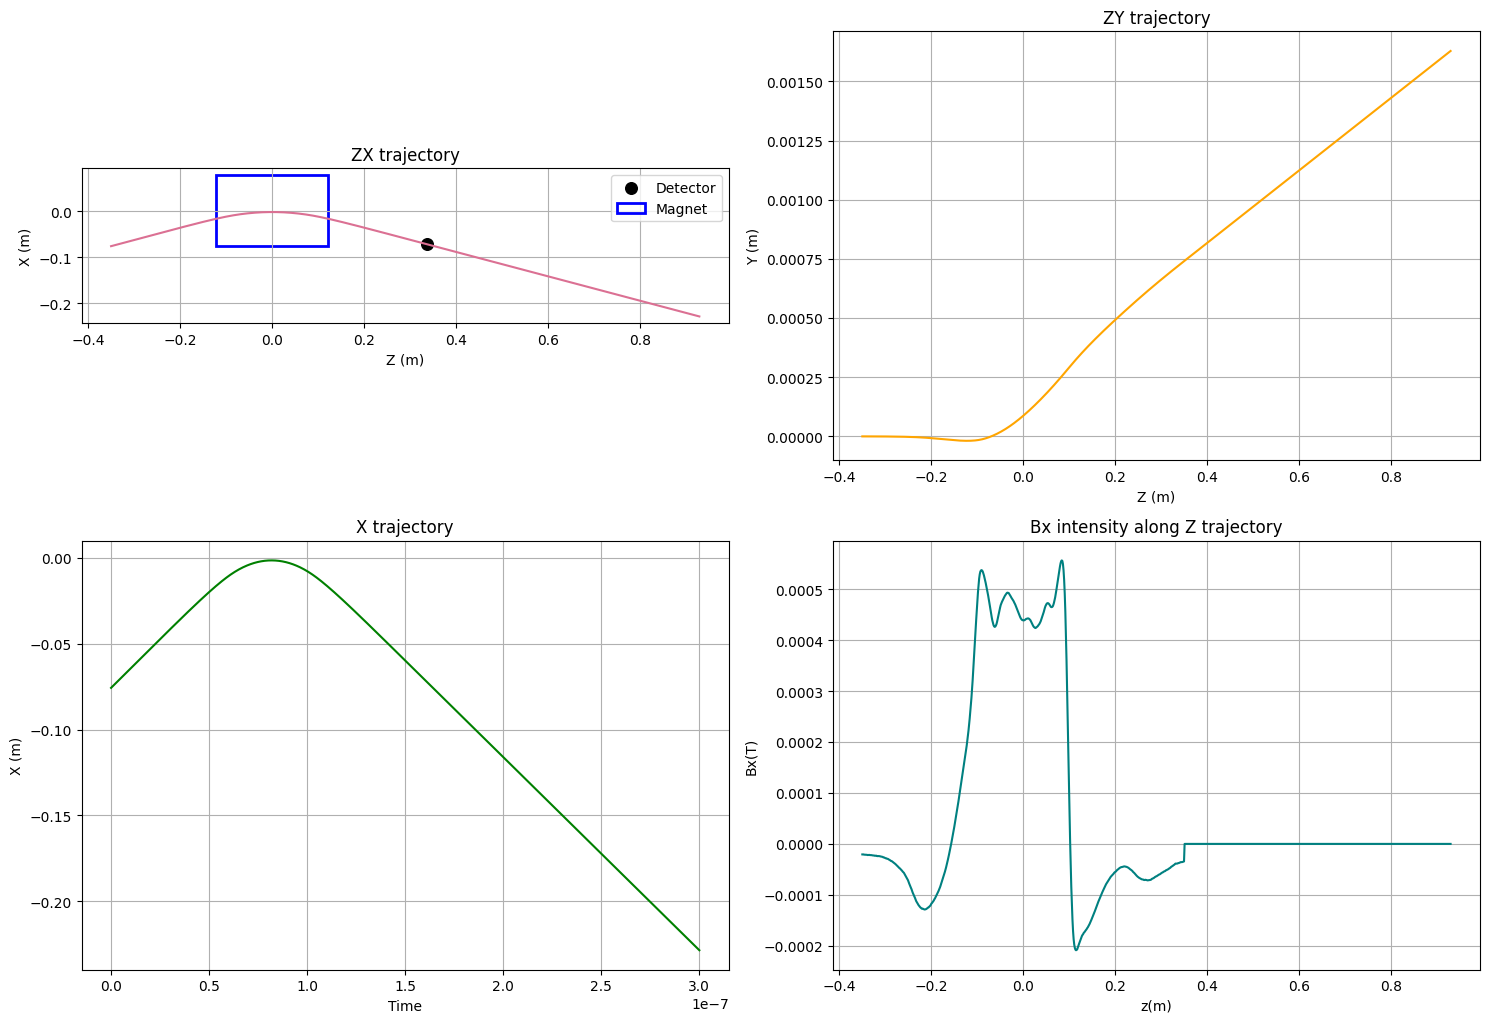

TRAJECTORY (5 A)


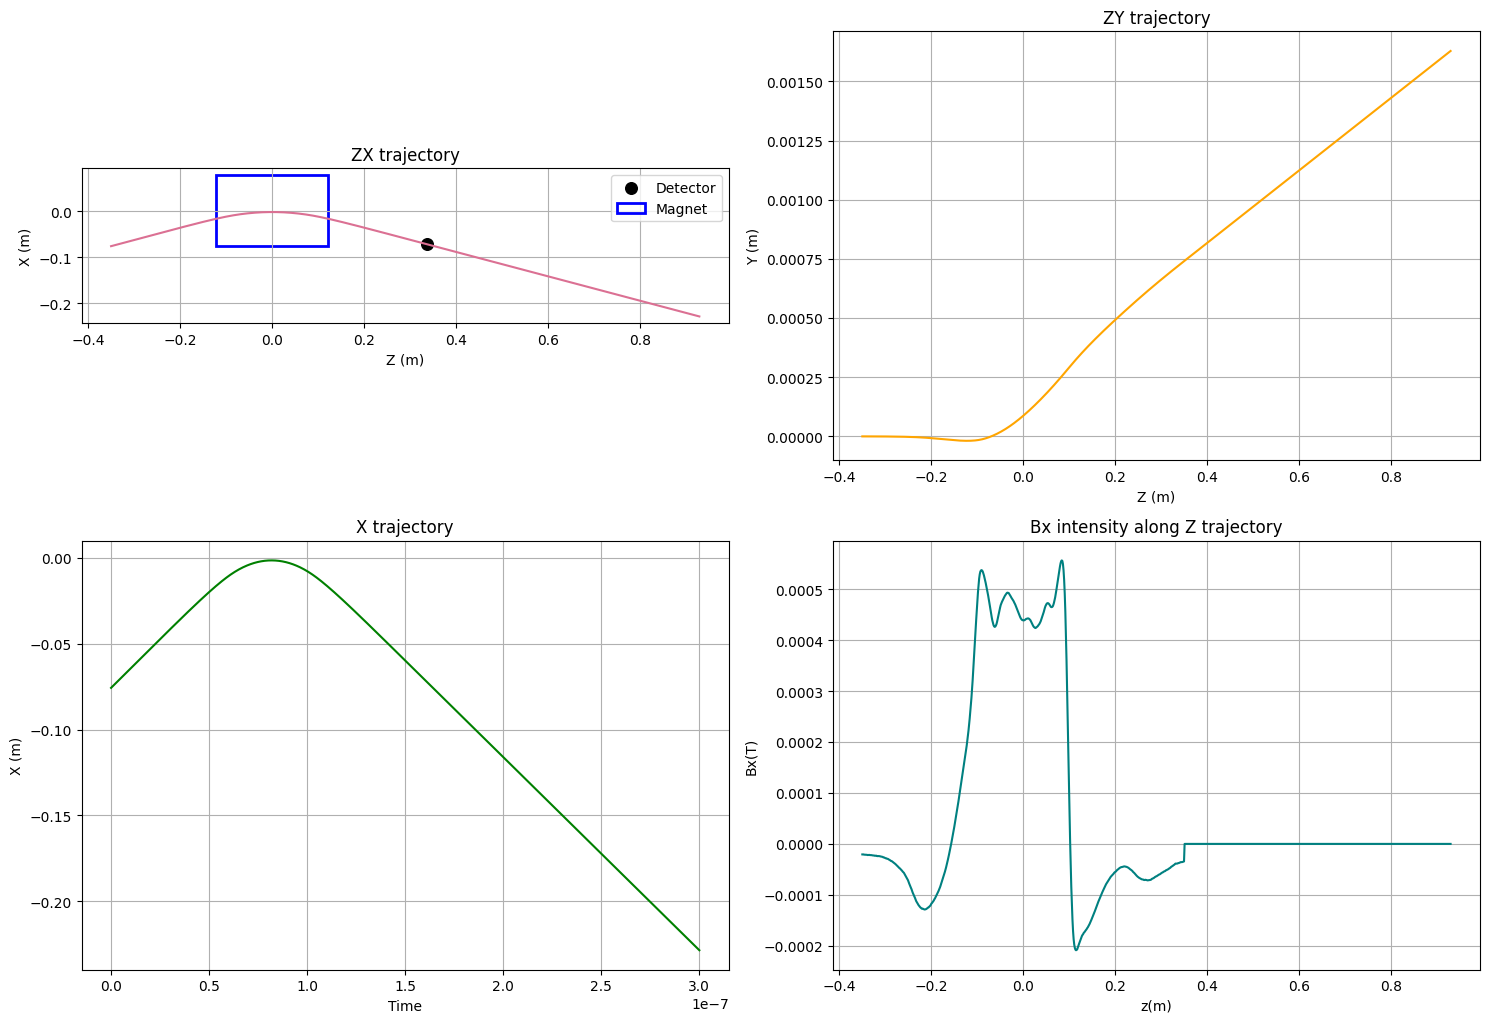

TRAJECTORY (2.5 A)


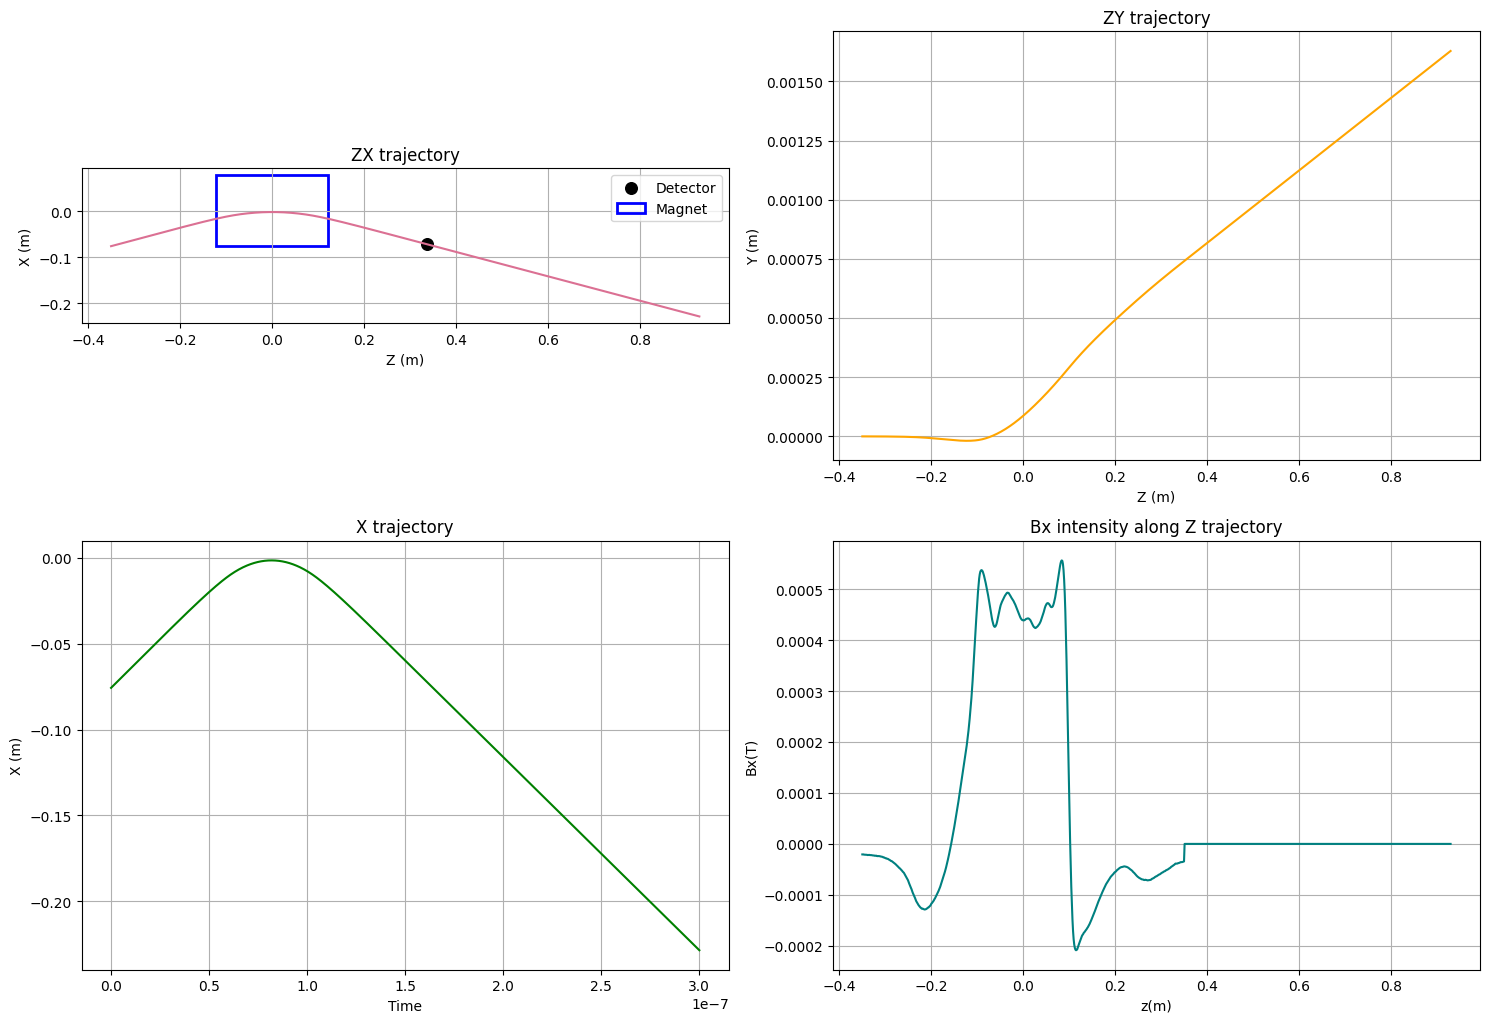

In [97]:
for file, current in zip(files, currents):
    print(f'TRAJECTORY ({current} A)')
    plot_2d_trajectory(traj, total_t, desired_x, desired_z)

### 4.2. I x E chart and plot

Saves the associated energy of each current value as a CSV, so it can be visualized later.

In [98]:
chart.to_csv('Current_and_energy_chart.csv', sep=' ')

Plots the informations of the chart.

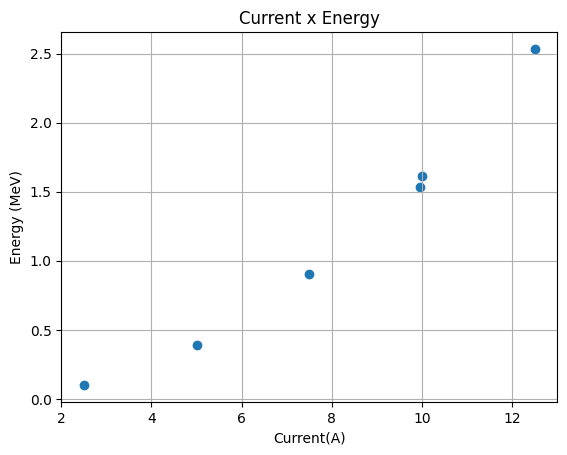

In [99]:
plt.scatter(chart['Current(A)'], chart['Energy(MeV)'])
plt.title('Current x Energy')
plt.xlabel('Current(A)')
plt.ylabel('Energy (MeV)')
plt.grid(True)
plt.show() 

### 4.3. I x E function

The next cell is used to find the best model and parameters for the functions. If you already know your function's model and parameters, you can substitute them in the variables.

In [100]:
def linear(x, a, b):
    return a * x + b

def polynomial2(x, a, b, c):
    return a * x**2 + b * x + c

def exponential(x, a, b):
    return a * np.exp(b * x)

def logarithmic(x, a, b):
    return a * np.log(x) + b

def power_law(x, a, b):
    return a * np.power(x, b)

models = {
    "Linear": (linear, [1, 1]),
    "Quadratic": (polynomial2, [1, 1, 1]),
    "Exponential": (exponential, [1, 0.1]),
    "Logarithmic": (logarithmic, [1, 1]),
    "Power Law": (power_law, [1, 1])
}

model01 = None
model02 = None
best_r2_01 = -np.inf
best_r2_02 = -np.inf
best_params01 = None
best_params02 =None

for name, (func, p0) in models.items():
    try:
        popt, _ = curve_fit(func, chart['Current(A)'], chart['Energy(MeV)'], p0=p0, maxfev=5000)
        y_pred = func(chart['Current(A)'], *popt)
        r2 = r2_score(chart['Energy(MeV)'], y_pred)
        
        if r2 > best_r2_01:
            best_r2_01 = r2
            model01 = (name, func)
            best_params01 = popt
    except Exception as e:
        print(f"{name} fitting failed: {e}")

for name, (func, p0) in models.items():
    try:
        popt, _ = curve_fit(func, chart['Energy(MeV)'], chart['Current(A)'], p0=p0, maxfev=5000)
        y_pred = func(chart['Energy(MeV)'], *popt)
        r2 = r2_score(chart['Current(A)'], y_pred)
        
        if r2 > best_r2_02:
            best_r2_02 = r2
            model02 = (name, func)
            best_params02 = popt
    except Exception as e:
        print(f"{name} fitting failed: {e}")

Plots the same informations as the graph above, but also fits a curve and show a function associating the values.

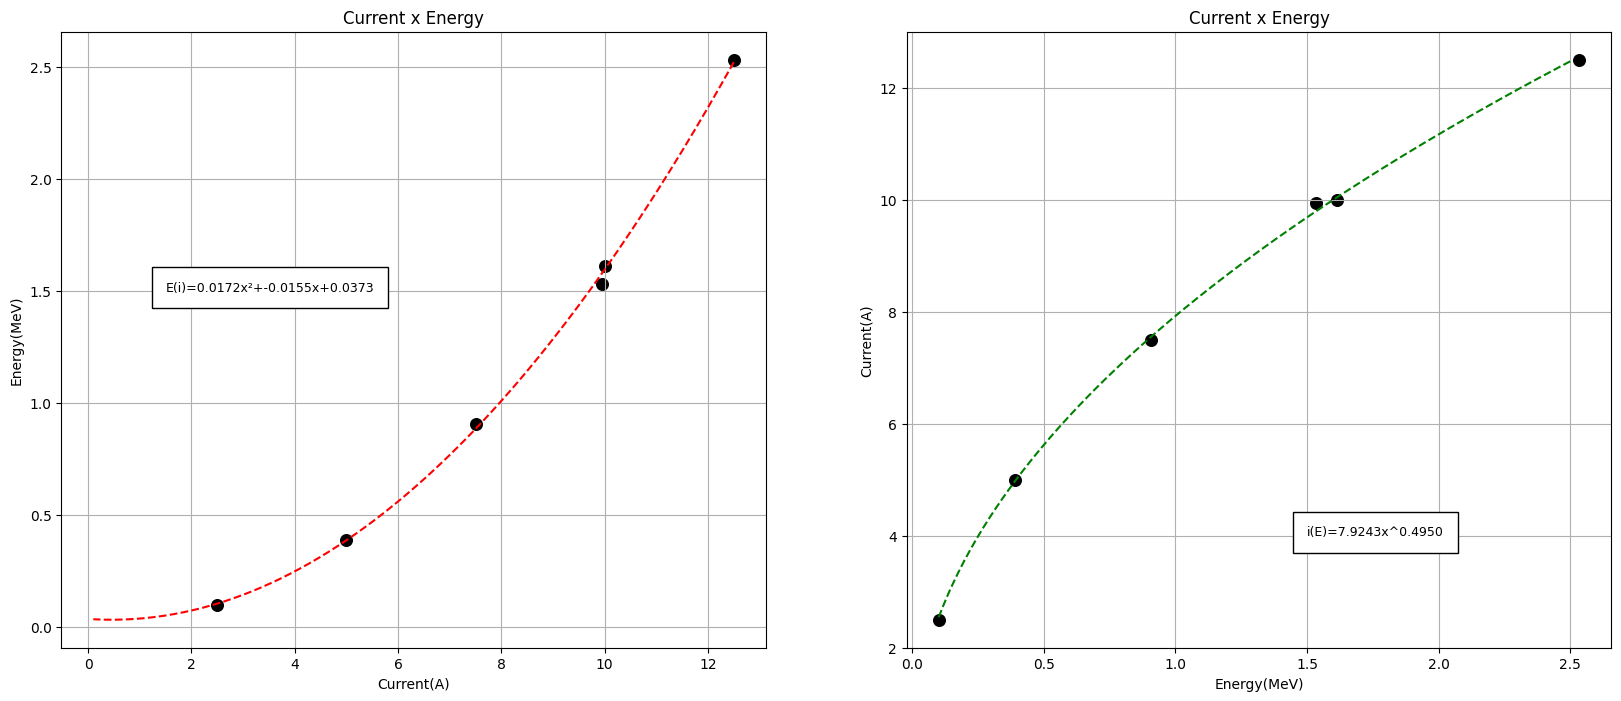

In [104]:
fig = plt.figure(figsize=(20, 8))
ax1 = fig.add_subplot(121) 
ax2 = fig.add_subplot(122)

if model01:
    name, func = model01

    x_pred = np.linspace(max(chart['Current(A)']), min(chart['Energy(MeV)']), 200)
    y_pred_curve = func(x_pred, *best_params01)

params01 = [float(best_params01[0]),
            float(best_params01[1]),
            float(best_params01[2])]

ax1.scatter(chart['Current(A)'], chart['Energy(MeV)'], s=70, color='k')
ax1.plot(x_pred, y_pred_curve, color='r', linestyle='--')
ax1.set_xlabel('Current(A)')
ax1.set_ylabel('Energy(MeV)')
ax1.set_title('Current x Energy')
ax1.grid(True)
ax1.text(1.5, 1.5, f'E(i)={params01[0]:.4f}x²+{params01[1]:.4f}x+{params01[2]:.4f}', fontsize=9, color='black', bbox={'facecolor': 'white', 'pad': 10})



if model02:
    name, func = model02

    x_pred = np.linspace(min(chart['Energy(MeV)']), min(chart['Current(A)']), 200)
    y_pred_curve = func(x_pred, *best_params02)

params02 = [float(best_params02[0]),
            float(best_params02[1])]

ax2.scatter(chart['Energy(MeV)'], chart['Current(A)'], s=70, color='k')
ax2.plot(x_pred, y_pred_curve, color='g', linestyle='--')
ax2.set_xlabel('Energy(MeV)')
ax2.set_ylabel('Current(A)')
ax2.set_title('Current x Energy')
ax2.grid(True)

plt.text(1.5, 4, f'i(E)={params02[0]:.4f}x^{params02[1]:.4f}', fontsize=9, color='black', bbox={'facecolor': 'white', 'pad': 10})

plt.savefig('Energy_and_Current_functions_graph.png', dpi=300, bbox_inches='tight')
